In [1]:
from __future__ import annotations

import io
import fitz
from PIL import Image
from pathlib import Path
from pprint import pprint
from IPython.display import display

from statistics import median
from dataclasses import dataclass

from typing import Any, Dict, Iterable, List, Mapping, Optional, Sequence, Tuple

In [2]:
import json
from pathlib import Path
from docling.document_converter import DocumentConverter
from docling.datamodel.document import DoclingDocument
from docling_core.types.doc.document import PictureItem

In [7]:
from functionalities.layout_geometry import *

In [3]:
def load_docling_document(pdf_path: str | Path) -> DoclingDocument:
    """
    Load a DoclingDocument from cache if available.
    Otherwise, convert the PDF and create the cache automatically.
    """

    pdf_path = Path(pdf_path)

    if not pdf_path.exists():
        raise FileNotFoundError(f"PDF not found: {pdf_path}")

    # Auto-generate cache path
    cache_path = pdf_path.with_suffix(".docling.json")

    # Load from cache
    if cache_path.exists():
        print(f"✅ Cache found. Loading cached document: {cache_path}")
        doc = DoclingDocument.load_from_json(cache_path)
        print(f"✅ Cache loaded as DoclingDocument")

    # Convert PDF and create cache
    else:
        print("⚠️ Cache not found.")
        print("⏳ Converting PDF using Docling DocumentConverter...")

        converter = DocumentConverter()
        result = converter.convert(pdf_path)
        doc = result.document

        # Save cache for future reuse
        doc.save_as_json(cache_path)

        print(f"✅ Conversion complete.")
        print(f"💾 Cache saved to: {cache_path}")

    # -----------------------------
    # Print document metadata
    # -----------------------------
    print("\n📄 Document Metadata")
    print("-" * 40)

    try:
        print(f"File Name      : {pdf_path.name}")
        print(f"Total Pages    : {len(doc.pages)}")
        print(f"Total Tables   : {len(doc.tables)}")
        print(f"Total Pictures : {len(doc.pictures)}")

        # Optional additional stats
        if hasattr(doc, "texts"):
            print(f"Text Blocks    : {len(doc.texts)}")

    except Exception as e:
        print(f"⚠️ Could not extract full metadata: {e}")

    print("-" * 40)

    return doc

In [5]:
# Example usage
food_pdf_path = (
    "/mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/"
    "iid-platform/sample_data/named/"
    "govt-food-data-report-large-table-heavy.pdf"
    # "nature-alberta-spring-2026-magazine-medium-mix-multi-col-text.pdf"
)
birds_pdf_path = (
    "/mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/"
    "iid-platform/sample_data/named/"
    "nature-alberta-spring-2026-magazine-medium-mix-multi-col-text.pdf"
)
food_doc = load_docling_document(food_pdf_path)
birds_doc = load_docling_document(birds_pdf_path)
food_fitz_pdf = fitz.open(food_pdf_path)
birds_fitz_pdf = fitz.open(birds_pdf_path)

✅ Cache found. Loading cached document: /mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/iid-platform/sample_data/named/govt-food-data-report-large-table-heavy.docling.json
✅ Cache loaded as DoclingDocument

📄 Document Metadata
----------------------------------------
File Name      : govt-food-data-report-large-table-heavy.pdf
Total Pages    : 585
Total Tables   : 474
Total Pictures : 455
Text Blocks    : 2748
----------------------------------------
✅ Cache found. Loading cached document: /mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/iid-platform/sample_data/named/nature-alberta-spring-2026-magazine-medium-mix-multi-col-text.docling.json
✅ Cache loaded as DoclingDocument

📄 Document Metadata
----------------------------------------
File Name      : nature-alberta-spring-2026-magazine-medium-mix-multi-col-text.pdf
Total Pages    : 40
Total Tables   : 0
Total Pictures : 82
Text Blocks    : 744
----------------------------------------


**Food PDF Comparison: Example 1**

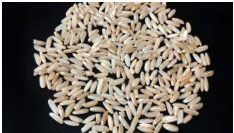

Figure Ref : #/pictures/36
Caption    : A013. Rice, raw, brown (Oryza sativa) ; A. Matia rangar chaul; G. Kathai chokha; H. Chawal; P. Bhura choul;  Kash. Tomul; Kh. Khaw saw; Mal. Kuthari ; M. Cheng; Tam. Arisi; Tel. Dampudu biyyam.



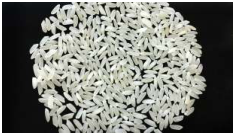

Figure Ref : #/pictures/37
Caption    : A015. Rice, raw, milled ( Oryza sativa ); A. Milat khunda chaul; B. Chowl; G. Choka; H. Chawal; Kan. Akki; Kash. Tomul;  Kh. Khaw boil; M. Cheng; Mar. Tondool; O. Chaula; P. Chaul;  Tam.   Arisi; Tel. Biyyam.



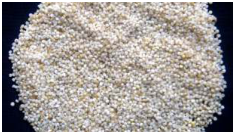

Figure Ref : #/pictures/38
Caption    : A017. Varagu ( Paspalum scrobiculatum );  A. Konidhan; B. Kodoadhan; G. Kodra; H. Koden; Kan. Harka; Kash. Snol; Mal. Koovaragu;  Mar. Karik; O. Kodus;  P. Kodra; Tam. Varagu; Tel.  Arikelu.



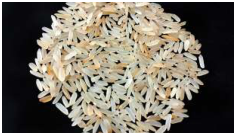

Figure Ref : #/pictures/39
Caption    : A014. Rice, parboiled, milled (Oryza sativa) ; A. Ukhua chaul;  B.  Siddha  chowl;  G.  Bafela  Chokha;  H.  Usna chawal; Kan. Kusubalakki; Kash. Tomul; Kh. Khaw boil; Mal. Puzhungal ari; M. Cheng; Mar. Ukadla tandool; O. Usuna chaula; P. Biga hua chawal;  Tam. Puzhungal arisi; Tel. Uppudu biyyam.



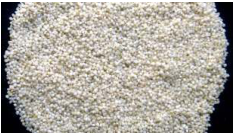

Figure Ref : #/pictures/40
Caption    : A016. Samai (Panicum miliare); B.  Sama;  G.  Kuri;  H. Shavan; Kan. Sama; Kash. Ganuhaar; Mal. Chama; Mar. Sava; O. Suan;  P. Swank; Tam. Samai; Tel. Sama.



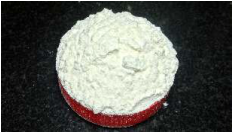

Figure Ref : #/pictures/41
Caption    : A018.  Wheat,  flour,  refined (Triticum  aestivum) ;  A. Moida; B. Maida; G. Maido;  H. Maida; Kan. Maida; Kash. Oat;  Kh.  Moida;  Mal.  Maida  mavu;  M.  Moida;  Mar. Maida; N. Maida; O. Maida; P. Maida;  Tam. Maida mavu; Tel. Maida pindi; U. Maida.

Processed 6 figure(s) from page 480.


In [9]:
config = LinkerConfig(direct_link_policy="trust") # trust boost ignore
export_page_figures(
    food_doc,
    food_fitz_pdf,
    page_no=480,
    zoom=1,
    mode="display",
    config=config,
)

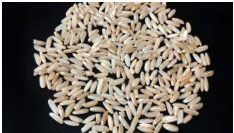

Figure Ref : #/pictures/36
Caption    : A013. Rice, raw, brown (Oryza sativa) ; A. Matia rangar chaul; G. Kathai chokha; H. Chawal; P. Bhura choul;  Kash. Tomul; Kh. Khaw saw; Mal. Kuthari ; M. Cheng; Tam. Arisi; Tel. Dampudu biyyam.



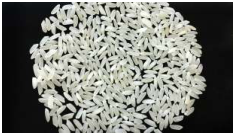

Figure Ref : #/pictures/37
Caption    : A015. Rice, raw, milled ( Oryza sativa ); A. Milat khunda chaul; B. Chowl; G. Choka; H. Chawal; Kan. Akki; Kash. Tomul;  Kh. Khaw boil; M. Cheng; Mar. Tondool; O. Chaula; P. Chaul;  Tam.   Arisi; Tel. Biyyam.



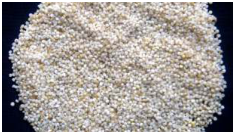

Figure Ref : #/pictures/38
Caption    : A017. Varagu ( Paspalum scrobiculatum );  A. Konidhan; B. Kodoadhan; G. Kodra; H. Koden; Kan. Harka; Kash. Snol; Mal. Koovaragu;  Mar. Karik; O. Kodus;  P. Kodra; Tam. Varagu; Tel.  Arikelu.



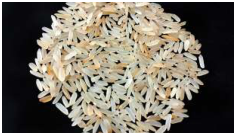

Figure Ref : #/pictures/39
Caption    : A014. Rice, parboiled, milled (Oryza sativa) ; A. Ukhua chaul;  B.  Siddha  chowl;  G.  Bafela  Chokha;  H.  Usna chawal; Kan. Kusubalakki; Kash. Tomul; Kh. Khaw boil; Mal. Puzhungal ari; M. Cheng; Mar. Ukadla tandool; O. Usuna chaula; P. Biga hua chawal;  Tam. Puzhungal arisi; Tel. Uppudu biyyam.



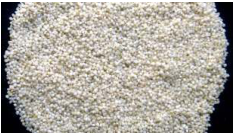

Figure Ref : #/pictures/40
Caption    : A016. Samai (Panicum miliare); B.  Sama;  G.  Kuri;  H. Shavan; Kan. Sama; Kash. Ganuhaar; Mal. Chama; Mar. Sava; O. Suan;  P. Swank; Tam. Samai; Tel. Sama.



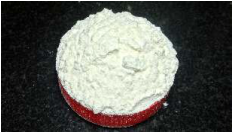

Figure Ref : #/pictures/41
Caption    : A018.  Wheat,  flour,  refined (Triticum  aestivum) ;  A. Moida; B. Maida; G. Maido;  H. Maida; Kan. Maida; Kash. Oat;  Kh.  Moida;  Mal.  Maida  mavu;  M.  Moida;  Mar. Maida; N. Maida; O. Maida; P. Maida;  Tam. Maida mavu; Tel. Maida pindi; U. Maida.

Processed 6 figure(s) from page 480.


In [10]:
config = LinkerConfig(direct_link_policy="boost") # trust boost ignore
export_page_figures(
    food_doc,
    food_fitz_pdf,
    page_no=480,
    zoom=1,
    mode="display",
    config=config,
)

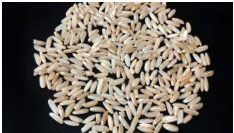

Figure Ref : #/pictures/36
Caption    : A013. Rice, raw, brown (Oryza sativa) ; A. Matia rangar chaul; G. Kathai chokha; H. Chawal; P. Bhura choul;  Kash. Tomul; Kh. Khaw saw; Mal. Kuthari ; M. Cheng; Tam. Arisi; Tel. Dampudu biyyam.



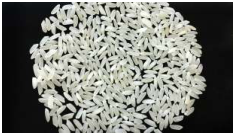

Figure Ref : #/pictures/37
Caption    : A015. Rice, raw, milled ( Oryza sativa ); A. Milat khunda chaul; B. Chowl; G. Choka; H. Chawal; Kan. Akki; Kash. Tomul;  Kh. Khaw boil; M. Cheng; Mar. Tondool; O. Chaula; P. Chaul;  Tam.   Arisi; Tel. Biyyam.



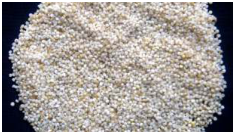

Figure Ref : #/pictures/38
Caption    : A017. Varagu ( Paspalum scrobiculatum );  A. Konidhan; B. Kodoadhan; G. Kodra; H. Koden; Kan. Harka; Kash. Snol; Mal. Koovaragu;  Mar. Karik; O. Kodus;  P. Kodra; Tam. Varagu; Tel.  Arikelu.



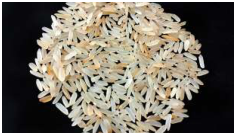

Figure Ref : #/pictures/39
Caption    : A014. Rice, parboiled, milled (Oryza sativa) ; A. Ukhua chaul;  B.  Siddha  chowl;  G.  Bafela  Chokha;  H.  Usna chawal; Kan. Kusubalakki; Kash. Tomul; Kh. Khaw boil; Mal. Puzhungal ari; M. Cheng; Mar. Ukadla tandool; O. Usuna chaula; P. Biga hua chawal;  Tam. Puzhungal arisi; Tel. Uppudu biyyam.



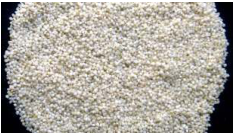

Figure Ref : #/pictures/40
Caption    : A016. Samai (Panicum miliare); B.  Sama;  G.  Kuri;  H. Shavan; Kan. Sama; Kash. Ganuhaar; Mal. Chama; Mar. Sava; O. Suan;  P. Swank; Tam. Samai; Tel. Sama.



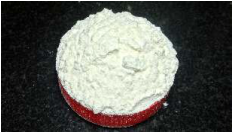

Figure Ref : #/pictures/41
Caption    : A018.  Wheat,  flour,  refined (Triticum  aestivum) ;  A. Moida; B. Maida; G. Maido;  H. Maida; Kan. Maida; Kash. Oat;  Kh.  Moida;  Mal.  Maida  mavu;  M.  Moida;  Mar. Maida; N. Maida; O. Maida; P. Maida;  Tam. Maida mavu; Tel. Maida pindi; U. Maida.

Processed 6 figure(s) from page 480.


In [11]:
config = LinkerConfig(direct_link_policy="ignore") # trust boost ignore
export_page_figures(
    food_doc,
    food_fitz_pdf,
    page_no=480,
    zoom=1,
    mode="display",
    config=config,
)

**Birds PDF Comparison: Example 1**

In [31]:
# birds_doc.texts

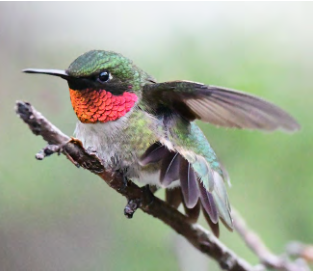

Figure Ref : #/pictures/20
Caption    : Hummingbirds often urinate while hovering, as this juvenile male rufous demonstrates.  MYRNA PEARMAN



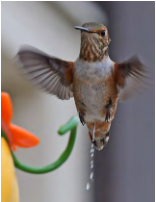

Figure Ref : #/pictures/21
Caption    : Few people realize that hummingbirds urinate. Since nectar is mostly water, hummingbirds excrete it through their kidneys, which are adapted to recapture



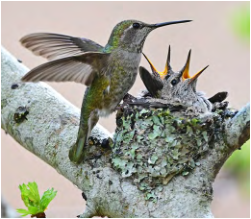

Figure Ref : #/pictures/22
Caption    : Left: An adult male ruby-throated hummingbird at rest, enjoying a good stretch and flaunting his bright gorget. MYRNA PEARMAN Above: Female hummingbirds, like this adult Anna's hummingbird, work tirelessly to feed their hungry nestlings. MYRNA PEARMAN

Processed 3 figure(s) from page 10.


In [12]:
config = LinkerConfig(direct_link_policy="trust") # trust boost ignore
export_page_figures(
    birds_doc,
    birds_fitz_pdf,
    page_no=10,
    zoom=1,
    mode="display",
    config=config,
)

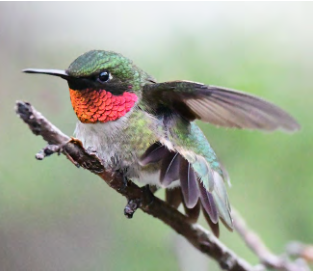

Figure Ref : #/pictures/20
Caption    : Hummingbirds often urinate while hovering, as this juvenile male rufous demonstrates.  MYRNA PEARMAN



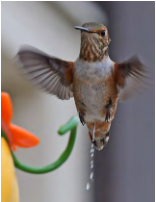

Figure Ref : #/pictures/21
Caption    : Few people realize that hummingbirds urinate. Since nectar is mostly water, hummingbirds excrete it through their kidneys, which are adapted to recapture



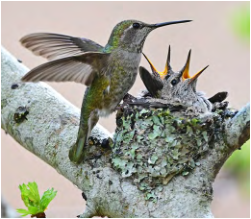

Figure Ref : #/pictures/22
Caption    : Left: An adult male ruby-throated hummingbird at rest, enjoying a good stretch and flaunting his bright gorget. MYRNA PEARMAN Above: Female hummingbirds, like this adult Anna's hummingbird, work tirelessly to feed their hungry nestlings. MYRNA PEARMAN

Processed 3 figure(s) from page 10.


In [13]:
config = LinkerConfig(direct_link_policy="boost") # trust boost ignore
export_page_figures(
    birds_doc,
    birds_fitz_pdf,
    page_no=10,
    zoom=1,
    mode="display",
    config=config,
)

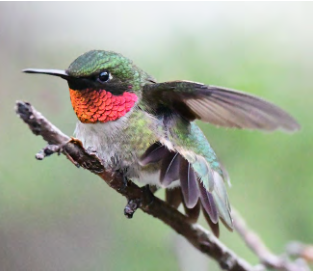

Figure Ref : #/pictures/20
Caption    : Left: An adult male ruby-throated hummingbird at rest, enjoying a good stretch and flaunting his bright gorget. MYRNA PEARMAN Above: Female hummingbirds, like this adult Anna's hummingbird, work tirelessly to feed their hungry nestlings. MYRNA PEARMAN



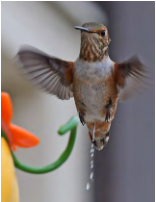

Figure Ref : #/pictures/21
Caption    : Hummingbirds often urinate while hovering, as this juvenile male rufous demonstrates.  MYRNA PEARMAN



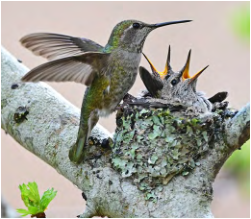

Figure Ref : #/pictures/22
Caption    : Creating HummingbirdFriendly Spaces

Processed 3 figure(s) from page 10.


In [14]:
config = LinkerConfig(direct_link_policy="ignore") # trust boost ignore
export_page_figures(
    birds_doc,
    birds_fitz_pdf,
    page_no=10,
    zoom=1,
    mode="display",
    config=config,
)

In [18]:
birds_doc.pictures

[PictureItem(self_ref='#/pictures/0', parent=RefItem(cref='#/body'), children=[RefItem(cref='#/texts/1'), RefItem(cref='#/texts/2'), RefItem(cref='#/texts/3'), RefItem(cref='#/texts/4')], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.PICTURE: 'picture'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=482.4024658203125, t=756.8190689086914, r=594.837890625, b=732.1046447753906, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 0))], source=[], comments=[], captions=[], references=[], footnotes=[], image=None, annotations=[]),
 PictureItem(self_ref='#/pictures/1', parent=RefItem(cref='#/body'), children=[RefItem(cref='#/texts/12'), RefItem(cref='#/texts/13')], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.PICTURE: 'picture'>, prov=[ProvenanceItem(page_no=2, bbox=BoundingBox(l=109.3674087524414, t=733.0786170959473, r=229.9933319091797, b=637.7931671142578, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), ch

**Birds PDF Comparison: Example 2**

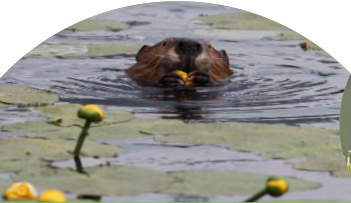

Figure Ref : #/pictures/31
Caption    : The boardwalk's namesake munching on the flowers of yellow pond lily. JASON TILLAPAUGH



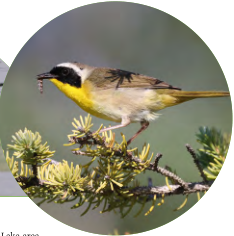

Figure Ref : #/pictures/32
Caption    : A common yellowthroat warbler picks up a snack in one of the boardwalk's spruce forests. JASON TILLAPAUGH



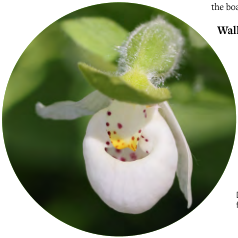

Figure Ref : #/pictures/33
Caption    : Delightful sparrow's egg lady's slipper can be found in the shaded, wet spruce forests. JASON TILLAPAUGH

Processed 3 figure(s) from page 17.


In [19]:
config = LinkerConfig(direct_link_policy="trust") # trust boost ignore
export_page_figures(
    birds_doc,
    birds_fitz_pdf,
    page_no=17,
    zoom=1,
    mode="display",
    config=config,
)

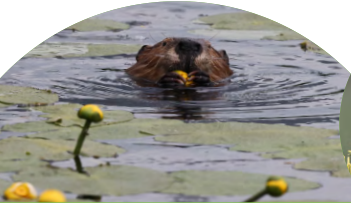

Figure Ref : #/pictures/31
Caption    : The boardwalk's namesake munching on the flowers of yellow pond lily. JASON TILLAPAUGH



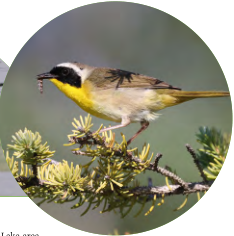

Figure Ref : #/pictures/32
Caption    : A common yellowthroat warbler picks up a snack in one of the boardwalk's spruce forests. JASON TILLAPAUGH



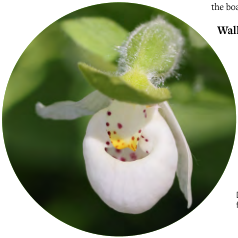

Figure Ref : #/pictures/33
Caption    : Delightful sparrow's egg lady's slipper can be found in the shaded, wet spruce forests. JASON TILLAPAUGH

Processed 3 figure(s) from page 17.


In [20]:
config = LinkerConfig(direct_link_policy="boost") # trust boost ignore
export_page_figures(
    birds_doc,
    birds_fitz_pdf,
    page_no=17,
    zoom=1,
    mode="display",
    config=config,
)

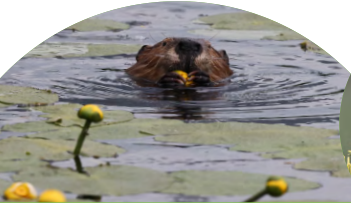

Figure Ref : #/pictures/31
Caption    : The boardwalk's namesake munching on the flowers of yellow pond lily. JASON TILLAPAUGH



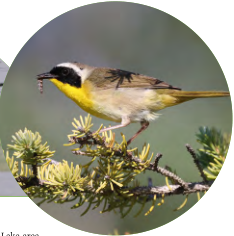

Figure Ref : #/pictures/32
Caption    : A common yellowthroat warbler picks up a snack in one of the boardwalk's spruce forests. JASON TILLAPAUGH



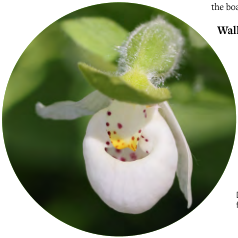

Figure Ref : #/pictures/33
Caption    : Delightful sparrow's egg lady's slipper can be found in the shaded, wet spruce forests. JASON TILLAPAUGH

Processed 3 figure(s) from page 17.


In [21]:
config = LinkerConfig(direct_link_policy="ignore") # trust boost ignore
export_page_figures(
    birds_doc,
    birds_fitz_pdf,
    page_no=17,
    zoom=1,
    mode="display",
    config=config,
)

**Birds PDF Comparison: Example 3**

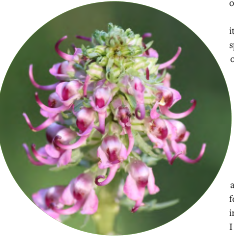

Figure Ref : #/pictures/34
Caption    : 16 |   SPRING 2026 NATURE ALBERTA MAGAZINE



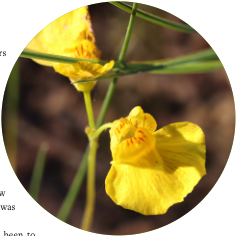

Figure Ref : #/pictures/35
Caption    : The aptly named elephant's head can be found right along the boardwalk throughout the fen. JASON TILLAPAUGH

Processed 2 figure(s) from page 18.


In [22]:
config = LinkerConfig(direct_link_policy="trust") # trust boost ignore
export_page_figures(
    birds_doc,
    birds_fitz_pdf,
    page_no=18,
    zoom=1,
    mode="display",
    config=config,
)

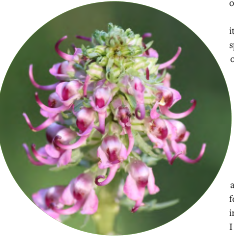

Figure Ref : #/pictures/34
Caption    : The aptly named elephant's head can be found right along the boardwalk throughout the fen. JASON TILLAPAUGH



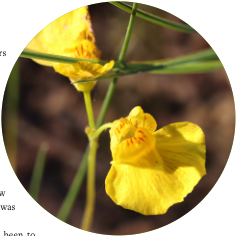

Figure Ref : #/pictures/35
Caption    : If you look closely in small pools of water within the fen, you'll see the small but showy yellow flowers of the carnivorous flat-leaved bladderwort. JASON TILLAPAUGH

Processed 2 figure(s) from page 18.


In [23]:
config = LinkerConfig(direct_link_policy="boost") # trust boost ignore
export_page_figures(
    birds_doc,
    birds_fitz_pdf,
    page_no=18,
    zoom=1,
    mode="display",
    config=config,
)

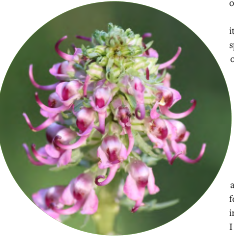

Figure Ref : #/pictures/34
Caption    : The aptly named elephant's head can be found right along the boardwalk throughout the fen. JASON TILLAPAUGH



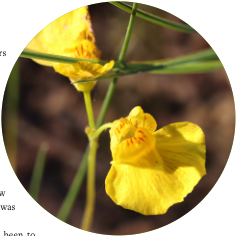

Figure Ref : #/pictures/35
Caption    : If you look closely in small pools of water within the fen, you'll see the small but showy yellow flowers of the carnivorous flat-leaved bladderwort. JASON TILLAPAUGH

Processed 2 figure(s) from page 18.


In [24]:
config = LinkerConfig(direct_link_policy="ignore") # trust boost ignore
export_page_figures(
    birds_doc,
    birds_fitz_pdf,
    page_no=18,
    zoom=1,
    mode="display",
    config=config,
)

**Birds PDF Comparison: Example 4**

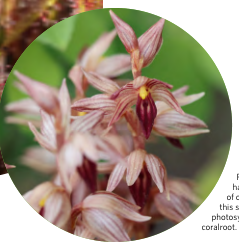

Figure Ref : #/pictures/36
Caption    : Left: The least common of Alberta's sundews, linear-leaved sundew can be found interspersed with flat-leaved bladderwort in the open water pools of the fen. JASON TILLAPAUGH



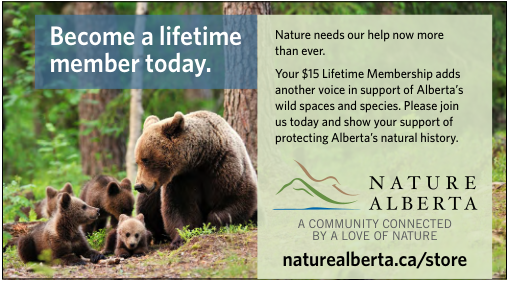

Figure Ref : #/pictures/37
Caption    : Become a lifetime member today.

Processed 2 figure(s) from page 19.


In [25]:
config = LinkerConfig(direct_link_policy="trust") # trust boost ignore
export_page_figures(
    birds_doc,
    birds_fitz_pdf,
    page_no=19,
    zoom=1,
    mode="display",
    config=config,
)

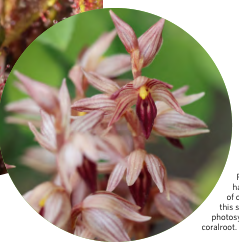

Figure Ref : #/pictures/36
Caption    : Left: The least common of Alberta's sundews, linear-leaved sundew can be found interspersed with flat-leaved bladderwort in the open water pools of the fen. JASON TILLAPAUGH



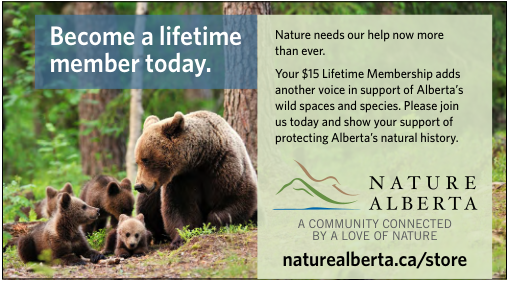

Figure Ref : #/pictures/37
Caption    : Become a lifetime member today.

Processed 2 figure(s) from page 19.


In [26]:
config = LinkerConfig(direct_link_policy="boost") # trust boost ignore
export_page_figures(
    birds_doc,
    birds_fitz_pdf,
    page_no=19,
    zoom=1,
    mode="display",
    config=config,
)

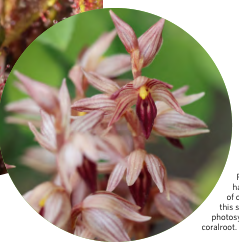

Figure Ref : #/pictures/36
Caption    : Left: The least common of Alberta's sundews, linear-leaved sundew can be found interspersed with flat-leaved bladderwort in the open water pools of the fen. JASON TILLAPAUGH



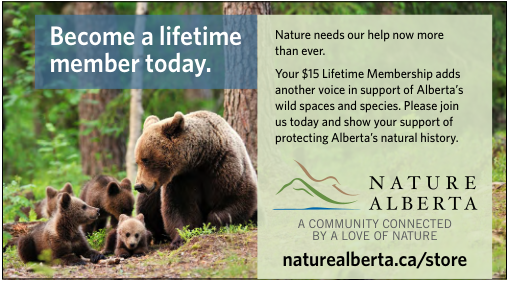

Figure Ref : #/pictures/37
Caption    : Become a lifetime member today.

Processed 2 figure(s) from page 19.


In [27]:
config = LinkerConfig(direct_link_policy="ignore") # trust boost ignore
export_page_figures(
    birds_doc,
    birds_fitz_pdf,
    page_no=19,
    zoom=1,
    mode="display",
    config=config,
)